## **Arabic** **OCR**

Install + Imports

In [ ]:
!pip install datasets jiwer -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
from datasets import load_dataset

from PIL import Image
import matplotlib.pyplot as plt
import re
from tqdm import tqdm
from google.colab import files

import cv2
import numpy as np
import random

from jiwer import wer, cer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.8 MB/s eta 0:00:00


 Load Arabic Dataset

In [ ]:
arabic_dataset = load_dataset("aamijar/muharaf-public", split="train")

arabic_dataset = arabic_dataset.shuffle(seed=42).select(
    range(min(50000, len(arabic_dataset)))
)

arabic_split = arabic_dataset.train_test_split(
    test_size=0.2,
    seed=42
)

arabic_train_data = arabic_split["train"]
arabic_val_data = arabic_split["test"]

print("Arabic Train:", len(arabic_train_data))
print("Arabic Validation:", len(arabic_val_data))
print(arabic_dataset[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.35k [00:00<?, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/385M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/399M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/403M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/70.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/22092 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1069 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1334 [00:00<?, ? examples/s]

Arabic Train: 17673
Arabic Validation: 4419
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=600x60 at 0x7FAD7DA71010>, 'text': 'بطول حياتكم الثمينة الحافلة بجلائل الفضائل وضروب الجهاد في سبيل الدين والوطن'}


Arabic Text Processing

In [ ]:
def clean_arabic_text(text):
    text = str(text)

    # Keep Arabic letters and spaces only
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def get_arabic_text(item):
    return item["text"]

Arabic Vocabulary

In [ ]:
arabic_texts = [
    clean_arabic_text(get_arabic_text(item))
    for item in arabic_train_data
]

arabic_chars = sorted(
    list(set("".join(arabic_texts)))
)

AR_PAD_TOKEN = "<PAD>"
AR_SOS_TOKEN = "<SOS>"
AR_EOS_TOKEN = "<EOS>"

ar_itos = [AR_PAD_TOKEN, AR_SOS_TOKEN, AR_EOS_TOKEN] + arabic_chars
ar_stoi = {ch: i for i, ch in enumerate(ar_itos)}

ar_pad_id = ar_stoi[AR_PAD_TOKEN]
ar_sos_id = ar_stoi[AR_SOS_TOKEN]
ar_eos_id = ar_stoi[AR_EOS_TOKEN]

ar_vocab_size = len(ar_itos)

print("Arabic Vocab Size:", ar_vocab_size)
print(ar_itos)

Arabic Vocab Size: 67
['<PAD>', '<SOS>', '<EOS>', ' ', '،', '؛', '؟', 'ء', 'آ', 'أ', 'ؤ', 'إ', 'ئ', 'ا', 'ب', 'ة', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ـ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ى', 'ي', 'ً', 'ٌ', 'ٍ', 'َ', 'ُ', 'ِ', 'ّ', 'ْ', '٠', '١', '٢', '٣', '٤', '٥', '٦', '٧', '٨', '٩', 'ڤ', 'ڨ', '۳', '۷', '۹']


Arabic Encode / Decode

In [ ]:
def encode_arabic_text(text, max_len=96):
    text = clean_arabic_text(text)

    ids = []

    for ch in text:
        if ch in ar_stoi:
            ids.append(ar_stoi[ch])

    ids = ids[:max_len - 2]

    return [ar_sos_id] + ids + [ar_eos_id]


def decode_arabic_ids(ids):
    result = []

    for i in ids:
        if i in [ar_pad_id, ar_sos_id, ar_eos_id]:
            continue

        if i < len(ar_itos):
            result.append(ar_itos[i])

    return "".join(result)

Arabic Transforms

In [ ]:
arabic_train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),

    transforms.RandomApply([
        transforms.RandomRotation(degrees=3),
    ], p=0.4),

    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3),
    ], p=0.2),

    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3
    ),

    transforms.Resize((64, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

arabic_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),

    # Light preprocessing to improve image consistency
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3),
    ], p=0.3),

    transforms.Resize((64, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

Arabic Dataset Class

In [ ]:
class ArabicHandwritingDataset(Dataset):
    def __init__(self, hf_dataset, transform, max_len=96):
        self.data = hf_dataset
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        image = item["image"]

        if not isinstance(image, Image.Image):
            image = Image.open(image).convert("RGB")

        image = self.transform(image)

        text = clean_arabic_text(get_arabic_text(item))
        seq = encode_arabic_text(text, self.max_len)

        return image, torch.tensor(seq, dtype=torch.long), text

Arabic Collate + DataLoader

In [ ]:
def arabic_collate_fn(batch):
    images, seqs, texts = zip(*batch)

    images = torch.stack(images)

    max_len = max(len(seq) for seq in seqs)

    padded_seqs = torch.full(
        (len(seqs), max_len),
        ar_pad_id,
        dtype=torch.long
    )

    for i, seq in enumerate(seqs):
        padded_seqs[i, :len(seq)] = seq

    return images, padded_seqs, texts


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

arabic_batch_size = 8

arabic_train_loader = DataLoader(
    ArabicHandwritingDataset(arabic_train_data, arabic_train_transform),
    batch_size=arabic_batch_size,
    shuffle=True,
    collate_fn=arabic_collate_fn
)

arabic_val_loader = DataLoader(
    ArabicHandwritingDataset(arabic_val_data, arabic_test_transform),
    batch_size=arabic_batch_size,
    shuffle=False,
    collate_fn=arabic_collate_fn
)

Device: cuda


Hybrid CRNN + TrOCR-like Model

In [ ]:
class CRNNTrOCR(nn.Module):
    def __init__(self, vocab_size, pad_id, d_model=256):
        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d((2, 1))
        )

        # BiLSTM sequence encoder
        self.rnn = nn.LSTM(
            input_size=256 * 8,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.2
        )

        self.dropout = nn.Dropout(0.3)

        self.feature_projection = nn.Linear(512, d_model)

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(200, d_model)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=4,
            batch_first=True,
            dropout=0.3
        )

        self.decoder = nn.TransformerDecoder(
            decoder_layer,
            num_layers=3
        )

        self.fc = nn.Linear(d_model, vocab_size)

        self.pad_id = pad_id

    def forward(self, images, target_seq):
        x = self.cnn(images)

        b, c, h, w = x.shape

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(b, w, c * h)

        x, _ = self.rnn(x)

        x = self.dropout(x)

        memory = self.feature_projection(x)

        seq_len = target_seq.size(1)

        positions = torch.arange(seq_len).unsqueeze(0).to(target_seq.device)

        tgt = self.embedding(target_seq) + self.pos_embedding(positions)

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            seq_len
        ).to(target_seq.device)

        tgt_key_padding_mask = (target_seq == self.pad_id)

        out = self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )

        logits = self.fc(out)

        return logits

Train Arabic Model

In [ ]:
def predict_arabic(model, image, max_len=96):
    model.eval()

    if not isinstance(image, Image.Image):
        image = Image.open(image).convert("RGB")

    image_tensor = arabic_test_transform(image).unsqueeze(0).to(device)

    generated = [ar_sos_id]

    with torch.no_grad():
        for _ in range(max_len):
            input_seq = torch.tensor(
                generated,
                dtype=torch.long
            ).unsqueeze(0).to(device)

            outputs = model(image_tensor, input_seq)

            next_id = outputs[0, -1].argmax().item()

            if next_id == ar_eos_id:
                break

            generated.append(next_id)

    return decode_arabic_ids(generated)

In [ ]:
from jiwer import cer, wer

arabic_model = CRNNTrOCR(
    vocab_size=ar_vocab_size,
    pad_id=ar_pad_id
).to(device)

arabic_criterion = nn.CrossEntropyLoss(ignore_index=ar_pad_id)

arabic_optimizer = torch.optim.Adam(
    arabic_model.parameters(),
    lr=0.0001,
    weight_decay=1e-5
)

arabic_epochs = 50
arabic_patience = 5

best_arabic_val_loss = float("inf")
arabic_patience_counter = 0

arabic_train_losses = []
arabic_val_losses = []
arabic_cer_scores = []
arabic_wer_scores = []
arabic_acc_scores = []

# يحسب المقاييس على عدد بسيط عشان ما يطول التدريب
def evaluate_arabic_metrics(model, data, num_samples=100):
    true_texts = []
    pred_texts = []

    model.eval()

    with torch.no_grad():
        for i in range(min(num_samples, len(data))):
            item = data[i]

            image = item["image"]

            true_text = clean_arabic_text(
                get_arabic_text(item)
            )

            pred_text = predict_arabic(
                model,
                image
            )

            true_texts.append(true_text)
            pred_texts.append(pred_text)

    cer_score = cer(true_texts, pred_texts)
    wer_score = wer(true_texts, pred_texts)

    exact_match_acc = sum(
        t == p for t, p in zip(true_texts, pred_texts)
    ) / len(true_texts)

    return cer_score, wer_score, exact_match_acc


for epoch in range(arabic_epochs):

    arabic_model.train()
    train_loss = 0

    for images, seqs, texts in tqdm(arabic_train_loader):
        images = images.to(device)
        seqs = seqs.to(device)

        input_seq = seqs[:, :-1]
        target_seq = seqs[:, 1:]

        outputs = arabic_model(images, input_seq)

        loss = arabic_criterion(
            outputs.reshape(-1, ar_vocab_size),
            target_seq.reshape(-1)
        )

        arabic_optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            arabic_model.parameters(),
            max_norm=1.0
        )

        arabic_optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(arabic_train_loader)

    arabic_model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, seqs, texts in arabic_val_loader:
            images = images.to(device)
            seqs = seqs.to(device)

            input_seq = seqs[:, :-1]
            target_seq = seqs[:, 1:]

            outputs = arabic_model(images, input_seq)

            loss = arabic_criterion(
                outputs.reshape(-1, ar_vocab_size),
                target_seq.reshape(-1)
            )

            val_loss += loss.item()

    avg_val_loss = val_loss / len(arabic_val_loader)

    cer_score, wer_score, acc_score = evaluate_arabic_metrics(
        arabic_model,
        arabic_val_data,
        num_samples=100
    )

    arabic_train_losses.append(avg_train_loss)
    arabic_val_losses.append(avg_val_loss)
    arabic_cer_scores.append(cer_score)
    arabic_wer_scores.append(wer_score)
    arabic_acc_scores.append(acc_score)

    lr = arabic_optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch+1:02d}/{arabic_epochs} | "
        f"Train Loss: {avg_train_loss:.3f} | "
        f"Val Loss: {avg_val_loss:.3f} | "
        f"CER: {cer_score:.3f} | "
        f"WER: {wer_score:.3f} | "
        f"Acc: {acc_score:.3f} | "
        f"LR: {lr:.6f}"
    )

    if avg_val_loss < best_arabic_val_loss:
        best_arabic_val_loss = avg_val_loss
        arabic_patience_counter = 0

        torch.save(
            arabic_model.state_dict(),
            "best_crnn_trocr_arabic.pth"
        )

        print("Best Arabic model saved.")

    else:
        arabic_patience_counter += 1

        print(
            f"No improvement: "
            f"{arabic_patience_counter}/{arabic_patience}"
        )

    if arabic_patience_counter >= arabic_patience:
        print("Early stopping activated.")
        break

  0%|          | 0/2210 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(
100%|██████████| 2210/2210 [00:49<00:00, 44.22it/s]


Epoch 01/50 | Train Loss: 2.698 | Val Loss: 2.509 | CER: 1.117 | WER: 1.072 | Acc: 0.000 | LR: 0.000100
Best Arabic model saved.


100%|██████████| 2210/2210 [00:48<00:00, 46.00it/s]


Epoch 02/50 | Train Loss: 2.500 | Val Loss: 2.366 | CER: 1.000 | WER: 1.184 | Acc: 0.010 | LR: 0.000100
Best Arabic model saved.


100%|██████████| 2210/2210 [00:48<00:00, 45.85it/s]


...

Epoch 48/50 | Train Loss: 0.670 | Val Loss: 0.609 | CER: 0.290 | WER: 0.636 | Acc: 0.090 | LR: 0.000100
Best Arabic model saved.


100%|██████████| 2210/2210 [00:48<00:00, 45.57it/s]


Epoch 49/50 | Train Loss: 0.655 | Val Loss: 0.627 | CER: 0.271 | WER: 0.627 | Acc: 0.090 | LR: 0.000100
No improvement: 1/5


100%|██████████| 2210/2210 [00:48<00:00, 45.70it/s]


Epoch 50/50 | Train Loss: 0.640 | Val Loss: 0.605 | CER: 0.268 | WER: 0.612 | Acc: 0.090 | LR: 0.000100
Best Arabic model saved.


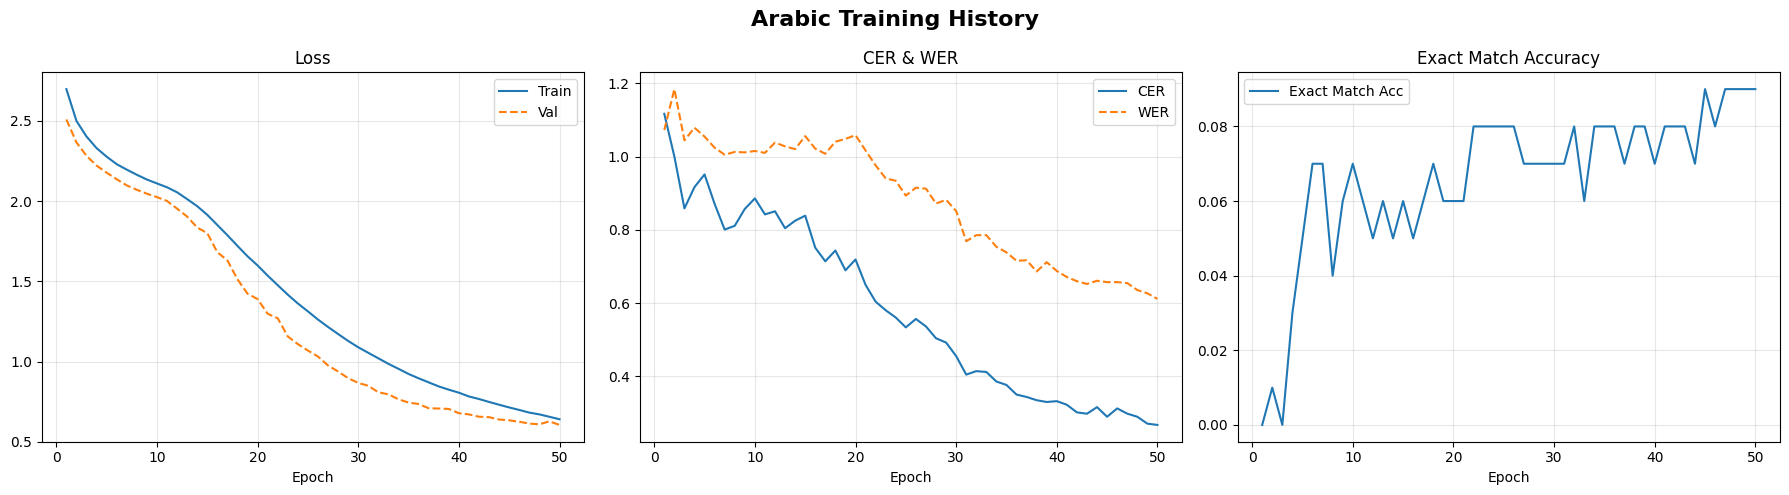

Plot saved: arabic_training_history.png


In [ ]:
epochs_x = range(1, len(arabic_train_losses) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Arabic Training History", fontsize=16, fontweight="bold")

# Loss
axes[0].plot(epochs_x, arabic_train_losses, label="Train")
axes[0].plot(epochs_x, arabic_val_losses, label="Val", linestyle="--")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CER & WER
axes[1].plot(epochs_x, arabic_cer_scores, label="CER")
axes[1].plot(epochs_x, arabic_wer_scores, label="WER", linestyle="--")
axes[1].set_title("CER & WER")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Accuracy
axes[2].plot(epochs_x, arabic_acc_scores, label="Exact Match Acc")
axes[2].set_title("Exact Match Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("arabic_training_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved: arabic_training_history.png")

In [ ]:
# Load best Arabic model
arabic_model.load_state_dict(
    torch.load("best_crnn_trocr_arabic.pth", map_location=device)
)

arabic_model.eval()

# Final evaluation on validation data
final_arabic_cer, final_arabic_wer, final_arabic_acc = evaluate_arabic_metrics(
    arabic_model,
    arabic_val_data,
    num_samples=500
)

final_arabic_val_loss = arabic_val_losses[-1]

print("FINAL ARABIC TEST RESULTS")
print(f"Val Loss        : {final_arabic_val_loss:.4f}")
print(f"CER             : {final_arabic_cer:.4f} ({final_arabic_cer*100:.2f}%)")
print(f"WER             : {final_arabic_wer:.4f} ({final_arabic_wer*100:.2f}%)")
print(f"Exact Match Acc : {final_arabic_acc:.4f} ({final_arabic_acc*100:.2f}%)")

FINAL ARABIC TEST RESULTS
Val Loss        : 0.6046
CER             : 0.2983 (29.83%)
WER             : 0.6294 (62.94%)
Exact Match Acc : 0.0980 (9.80%)


Arabic – Closest Character Suggestion (Top-K)

In [ ]:
# Closest Character Suggestion for Arabic
def predict_arabic_topk(model, image, max_len=96, top_k=3):
    """
    Returns the greedy prediction plus top-k character alternatives at each step.
    Returns:
        predicted_text (str)
        steps (list of dicts): each step has 'top_chars' and 'top_probs'
    """
    import torch.nn.functional as F

    model.eval()

    if not isinstance(image, Image.Image):
        image = Image.open(image).convert("RGB")

    image_tensor = arabic_test_transform(image).unsqueeze(0).to(device)

    generated = [ar_sos_id]
    steps = []

    with torch.no_grad():
        for _ in range(max_len):
            input_seq = torch.tensor(generated, dtype=torch.long).unsqueeze(0).to(device)
            outputs   = model(image_tensor, input_seq)          # (1, T, vocab)
            logits    = outputs[0, -1]                           # (vocab,)
            probs     = F.softmax(logits, dim=-1)

            topk_probs, topk_ids = probs.topk(top_k)
            top_chars = [ar_itos[i.item()] for i in topk_ids]
            top_probs = [round(p.item(), 4) for p in topk_probs]

            steps.append({"top_chars": top_chars, "top_probs": top_probs})

            best_id = topk_ids[0].item()
            if best_id == ar_eos_id:
                break
            generated.append(best_id)

    predicted_text = decode_arabic_ids(generated)
    return predicted_text, steps


# Demo
sample_item = arabic_val_data[0]
sample_img  = sample_item["image"]
true_text   = clean_arabic_text(get_arabic_text(sample_item))

pred_text, steps = predict_arabic_topk(arabic_model, sample_img, top_k=3)

print(f"True Text      : {true_text}")
print(f"Predicted Text : {pred_text}")
print()
print("Step-by-step top-3 character alternatives:")
for i, step in enumerate(steps[:len(pred_text)]):
    chosen = step["top_chars"][0]
    alts   = list(zip(step["top_chars"], step["top_probs"]))
    print(f"  Position {i+1:02d} → chosen: '{chosen}'  | alternatives: {alts}")

True Text      : مدرسة يبرود في ذلك الوقت لقرب انتها الفرصه وجا
Predicted Text : مدرسة يوود في ذلك الوقت لقرب انتها الفرضه وبعا

Step-by-step top-3 character alternatives:
  Position 01 → chosen: 'م'  | alternatives: [('م', 0.9693), ('ا', 0.0101), ('ص', 0.0097)]
  Position 02 → chosen: 'د'  | alternatives: [('د', 0.9569), ('و', 0.0178), ('ع', 0.0139)]
  Position 03 → chosen: 'ر'  | alternatives: [('ر', 0.9996), ('و', 0.0003), ('ا', 0.0001)]
  Position 04 → chosen: 'س'  | alternatives: [('س', 0.9991), ('و', 0.0004), ('ش', 0.0002)]
  Position 05 → chosen: 'ة'  | alternatives: [('ة', 0.9789), ('َ', 0.015), ('ت', 0.0046)]
  Position 06 → chosen: ' '  | alternatives: [(' ', 0.9839), ('ٍ', 0.015), ('ِ', 0.0007)]
  Position 07 → chosen: 'ي'  | alternatives: [('ي', 0.6241), ('ب', 0.3741), ('ل', 0.0015)]
  Position 08 → chosen: 'و'  | alternatives: [('و', 0.6761), ('ب', 0.2726), ('د', 0.0388)]
  Position 09 → chosen: 'و'  | alternatives: [('و', 0.6724), ('م', 0.1254), ('ر', 0.1208)]
  Position 

## Top-K Heatmap- Arabic

Ground Truth: مدرسة يبرود في ذلك الوقت لقرب انتها الفرصه وجا


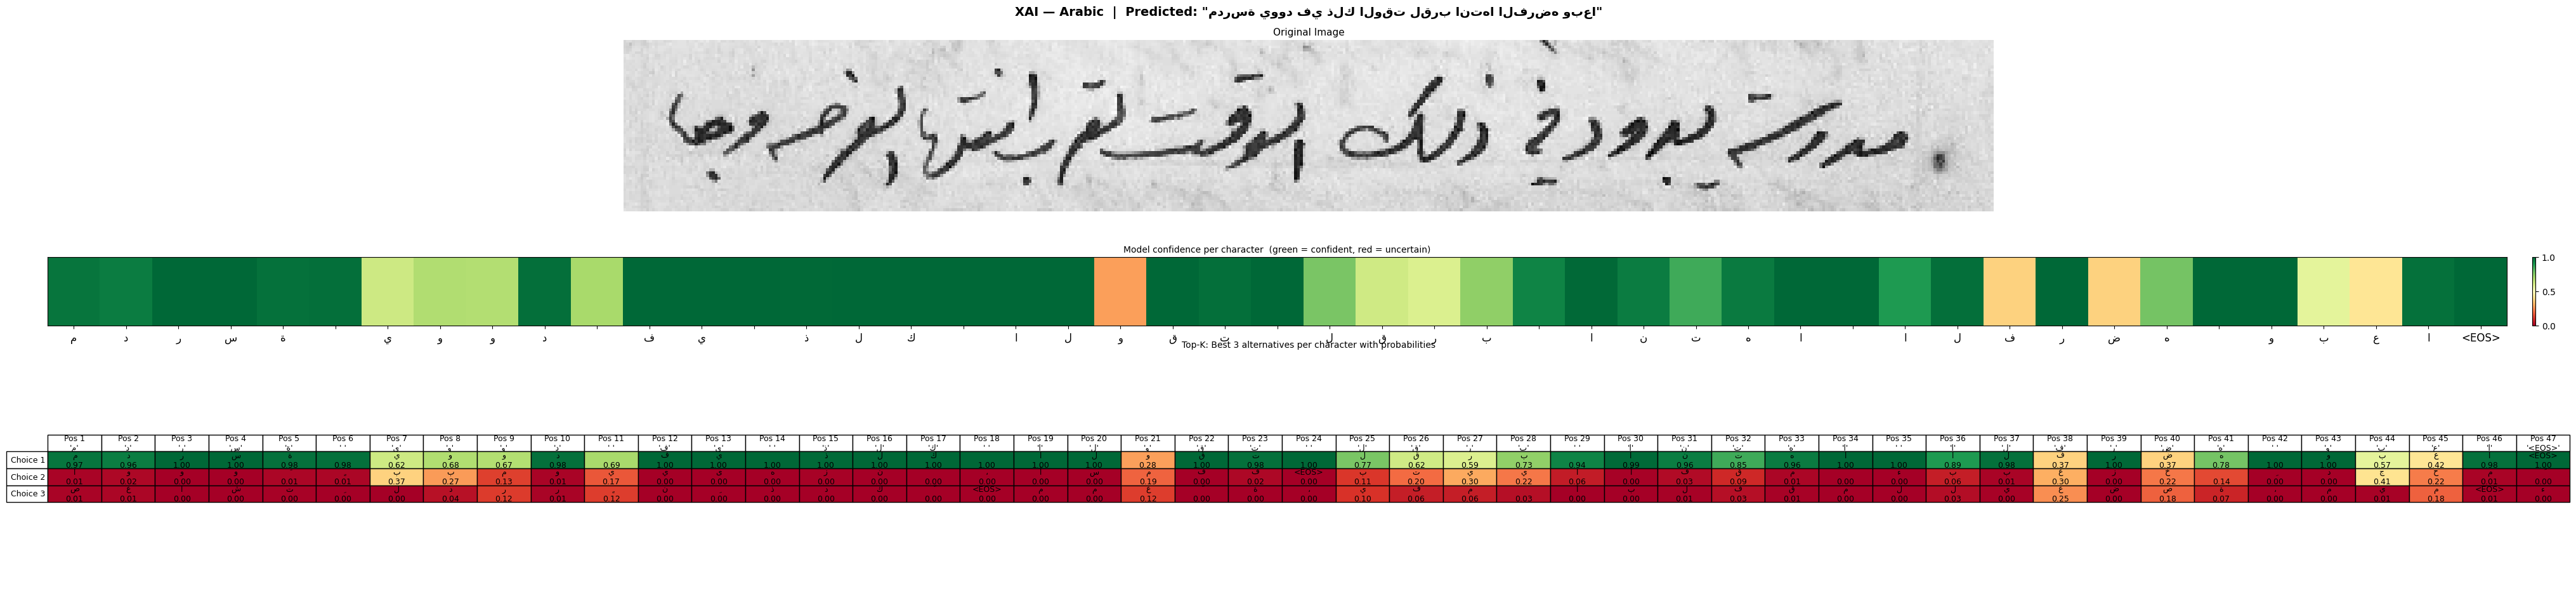

Predicted text: مدرسة يوود في ذلك الوقت لقرب انتها الفرضه وبعا
Saved: xai_arabic.png


In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def xai_arabic_topk(model, image, top_k=3, max_len=96):


    # Run the prediction and get the step-by-step top-k info
    pred_text, steps = predict_arabic_topk(model, image, max_len=max_len, top_k=top_k)

    if not steps:
        print("The model could not read the image.")
        return

    n_chars = len(steps)

    # Confidence = probability of the top pick at each character position
    confidences = [step["top_probs"][0] for step in steps]

    # Build the figure
    fig = plt.figure(figsize=(max(14, n_chars * 0.9), 9))
    fig.suptitle(
        f'XAI — Arabic  |  Predicted: "{pred_text}"',
        fontsize=14, fontweight="bold", y=1.01
    )

    # Section 1: Original image
    ax_img = fig.add_axes([0.03, 0.65, 0.94, 0.30])
    ax_img.imshow(image.convert("L"), cmap="gray")
    ax_img.set_title("Original Image", fontsize=11)
    ax_img.axis("off")

    #  Section 2: Confidence Heatmap
    ax_heat = fig.add_axes([0.03, 0.45, 0.94, 0.12])
    conf_array = np.array(confidences).reshape(1, -1)
    im = ax_heat.imshow(conf_array, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax_heat.set_xticks(range(n_chars))
    ax_heat.set_xticklabels(
        [step["top_chars"][0] for step in steps],
        fontsize=12
    )
    ax_heat.set_yticks([])
    ax_heat.set_title("Model confidence per character  (green = confident, red = uncertain)", fontsize=10)
    plt.colorbar(im, ax=ax_heat, orientation="vertical", fraction=0.015, pad=0.01)

    # Section 3: Top-K table
    ax_table = fig.add_axes([0.03, 0.0, 0.94, 0.40])
    ax_table.axis("off")

    # Column = character position, row = top-k rank
    col_labels = [f"Pos {i+1}\n'{steps[i]['top_chars'][0]}'" for i in range(n_chars)]
    row_labels = [f"Choice {k+1}" for k in range(top_k)]

    # Fill table with character + probability for each rank
    table_data = []
    for k in range(top_k):
        row = []
        for i in range(n_chars):
            char = steps[i]["top_chars"][k] if k < len(steps[i]["top_chars"]) else "-"
            prob = steps[i]["top_probs"][k] if k < len(steps[i]["top_probs"]) else 0.0
            row.append(f"{char}\n{prob:.2f}")
        table_data.append(row)

    # Color each cell based on its probability (green = high, red = low)
    cell_colors = []
    cmap = plt.cm.RdYlGn
    for k in range(top_k):
        row_colors = []
        for i in range(n_chars):
            prob = steps[i]["top_probs"][k] if k < len(steps[i]["top_probs"]) else 0.0
            color = cmap(prob)
            row_colors.append(color)
        cell_colors.append(row_colors)

    tbl = ax_table.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellColours=cell_colors,
        loc="center",
        cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)
    ax_table.set_title("Top-K: Best 3 alternatives per character with probabilities", fontsize=10, pad=8)

    plt.savefig("xai_arabic.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Predicted text: {pred_text}")
    print("Saved: xai_arabic.png")



sample_item  = arabic_val_data[0]
sample_image = sample_item["image"]
true_text    = clean_arabic_text(get_arabic_text(sample_item))

print(f"Ground Truth: {true_text}")
xai_arabic_topk(arabic_model, sample_image, top_k=3)


Arabic CER / WER

Show Arabic Random Samples

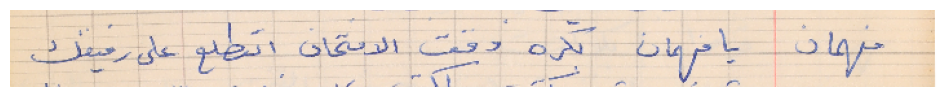

True Arabic Text:
فهمان يا فهمان بكره وقت الامتحان اتطلع على رفيقك

Predicted Arabic Text:
فهمان يا فهمان تكرى وفت الاعتمان اتطلع على رفيقك

--------------------------------------------------------------------------------



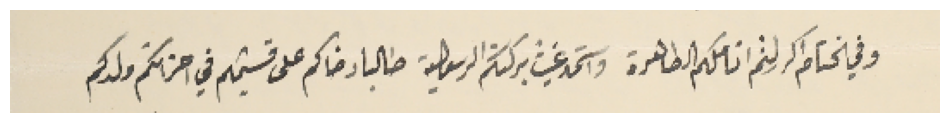

True Arabic Text:
وفي الختام اكرر لثم اناملكم الطاهرة واسَتمد غيث بركتكم الرسولية طالبا رضاكم على قسيمكم في احزانكم ولدكم

Predicted Arabic Text:
وفي الختام الطبق ان المحكم المطران والتماسَين بركتكم الرسلية حالباً وفاكم على شيخ في من من مدا

--------------------------------------------------------------------------------



In [ ]:
num_samples = 2

random_indices = random.sample(
    range(len(arabic_val_data)),
    num_samples
)

for idx in random_indices:
    item = arabic_val_data[idx]

    image = item["image"]

    true_text = clean_arabic_text(
        get_arabic_text(item)
    )

    predicted_text = predict_arabic(
        arabic_model,
        image
    )

    plt.figure(figsize=(12, 3))
    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.show()

    print("True Arabic Text:")
    print(true_text)

    print("\nPredicted Arabic Text:")
    print(predicted_text)

    print("\n" + "-" * 80 + "\n")

Arabic External Image

Saving Screenshot 2026-05-30 003951.png to Screenshot 2026-05-30 003951.png


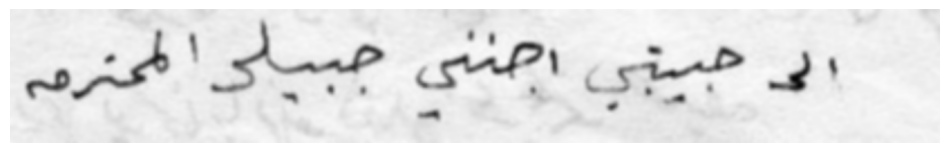

Predicted Arabic Text:
الى حبيبتي اجنني جبيلي المحترمه


In [ ]:
def preprocess_external_image_light(image_path):
    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    pil_img = Image.fromarray(gray).convert("RGB")

    return pil_img


uploaded = files.upload()

image_path = list(uploaded.keys())[0]

arabic_external_image = preprocess_external_image_light(image_path)

plt.figure(figsize=(12, 4))
plt.imshow(arabic_external_image, cmap="gray")
plt.axis("off")
plt.show()

arabic_prediction = predict_arabic(
    arabic_model,
    arabic_external_image
)

print("Predicted Arabic Text:")
print(arabic_prediction)

Save Arabic Model

In [ ]:
torch.save(
    arabic_model.state_dict(),
    "final_hybrid_crnn_trocr_arabic.pth"
)
print("Arabic model saved successfully.")

Arabic model saved successfully.


English


In [ ]:
!pip install torch torchvision datasets jiwer --quiet

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split
from datasets import load_dataset
from PIL import Image, ImageOps, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
from jiwer import wer, cer
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


Preprocessing Pipeline




In [ ]:
class ImagePreprocessor:

    def __init__(self, target_height=32, target_width=256):
        self.H = target_height
        self.W = target_width

    def to_grayscale(self, img: Image.Image) -> Image.Image:
        return img.convert('L')

    def denoise(self, img: Image.Image) -> Image.Image:
        #Median filter to remove noise
        return img.filter(ImageFilter.MedianFilter(size=3))

    def binarize(self, img: Image.Image) -> Image.Image:
        #Adaptive binarization
        arr = np.array(img, dtype=np.float32)
        threshold = arr.mean() - 0.5 * arr.std()
        binary = (arr > threshold).astype(np.uint8) * 255
        return Image.fromarray(binary)

    def deskew(self, img: Image.Image) -> Image.Image:
        #Projection Profile
        arr = np.array(img)
        best_angle, best_score = 0, -np.inf
        for angle in np.arange(-5, 5.5, 0.5):
            rotated = img.rotate(angle, expand=True, fillcolor=255)
            proj = np.sum(np.array(rotated) < 128, axis=1)
            score = np.sum((proj - proj.mean()) ** 2)
            if score > best_score:
                best_score, best_angle = score, angle
        return img.rotate(best_angle, expand=True, fillcolor=255)

    def aspect_resize(self, img: Image.Image) -> Image.Image:
        #Resize with padding
        w, h = img.size
        scale = self.H / h
        new_w = min(int(w * scale), self.W)
        img = img.resize((new_w, self.H), Image.LANCZOS)
        # target width
        padded = Image.new('L', (self.W, self.H), color=255)
        padded.paste(img, (0, 0))
        return padded

    def to_tensor(self, img: Image.Image) -> torch.Tensor:
        arr = np.array(img, dtype=np.float32) / 255.0
        arr = (arr - 0.5) / 0.5
        return torch.tensor(arr).unsqueeze(0)

    def __call__(self, img: Image.Image) -> torch.Tensor:
        img = self.to_grayscale(img)
        img = self.denoise(img)
        img = self.binarize(img)
        img = self.deskew(img)
        img = self.aspect_resize(img)
        return self.to_tensor(img)



full_preprocessor = ImagePreprocessor(target_height=32, target_width=256)

print('Preprocessors ready')

Preprocessors ready


Dataset

In [ ]:
raw = load_dataset('Teklia/IAM-line', split='train')

all_texts = [s['text'] for s in raw if s['text']]
chars     = ['<b>'] + sorted(set(''.join(all_texts)))
c2i = {c: i for i, c in enumerate(chars)}
i2c = {i: c for c, i in c2i.items()}
print(f'Vocab size: {len(chars)}')
print(f'Sample chars: {chars[1:20]}')

README.md:   0%|          | 0.00/2.14k [00:00<?, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

Vocab size: 80
Sample chars: [' ', '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4']


In [ ]:
class OCRDataset(Dataset):
    def __init__(self, data, preprocessor, use_full_preprocess=False):
        self.data = data
        self.preprocessor = preprocessor
        self.use_full = use_full_preprocess

    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        sample = self.data[i]
        img    = sample['image']
        text   = sample['text'] or ''

        if self.use_full:
            tensor = self.preprocessor(img)
        else:
            tensor = self.preprocessor(img)

        label = torch.tensor([c2i[c] for c in text if c in c2i], dtype=torch.long)
        return tensor, label, text


def collate_fn(batch):
    imgs, labels, texts = zip(*batch)
    return (
        torch.stack(imgs),
        torch.cat(labels),
        torch.tensor([len(l) for l in labels], dtype=torch.long),
        texts  #tuple of original strings
    )


# 70% Train 15% Val 15% Test
n       = len(raw)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val

full_dataset = OCRDataset(raw, full_preprocessor, use_full_preprocess=True)
train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 4537 | Val: 972 | Test: 973


CRNN Model

In [ ]:
class CRNN(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d((2,1)),
            # Block 4
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d((2,1)),
        )
        self.dropout = nn.Dropout(dropout)

        self.rnn = nn.LSTM(1024, 256, num_layers=2, batch_first=True,
                           bidirectional=True, dropout=dropout)
        self.fc  = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.cnn(x)                        #(B, C, H, W)
        b, c, h, w = x.size()
        x = x.permute(0, 3, 1, 2)             # (B, W, C, H)
        x = x.reshape(b, w, c * h)            #(B, W, C*H)
        x = self.dropout(x)
        x, _ = self.rnn(x)                    #(B, W, 512)
        x = self.dropout(x)
        x = self.fc(x)                        # (B, W, num_classes)
        return x.permute(1, 0, 2)             # (T, B, num_classes) to CTCLoss


model = CRNN(len(chars)).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,}')

Parameters: 8,746,704


CTC Decoder and  Metrics

In [ ]:
def ctc_greedy_decode(output: torch.Tensor) -> list[str]:
    """
    output: (T, B, num_classes) logits
    returns: list of decoded strings (length B)
    """
    preds = output.argmax(2).permute(1, 0)  #(B, T)
    decoded = []
    for seq in preds:
        tokens, prev = [], None
        for t in seq.tolist():
            if t != prev and t != 0:   # 0 = blank
                tokens.append(i2c[t])
            prev = t
        decoded.append(''.join(tokens))
    return decoded


def compute_metrics(loader, model, criterion) -> dict:

    model.eval()
    total_loss = 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for imgs, labels, lens, texts in loader:
            imgs = imgs.to(device)
            out  = model(imgs)  #(T, B, C)
            T_   = out.size(0)
            loss = criterion(
                out.log_softmax(2),
                labels,
                torch.full((imgs.size(0),), T_, dtype=torch.long),
                lens
            )
            total_loss += loss.item()

            preds = ctc_greedy_decode(out.cpu())
            all_preds.extend(preds)
            all_targets.extend(texts)

    avg_loss = total_loss / len(loader)

    # CER , WER from jiwer

    valid = [(p, t) for p, t in zip(all_preds, all_targets) if t.strip()]
    if valid:
        p_list, t_list = zip(*valid)
        char_error  = cer(list(t_list), list(p_list))
        word_error  = wer(list(t_list), list(p_list))
        exact_match = sum(p == t for p, t in zip(p_list, t_list)) / len(p_list)
    else:
        char_error = word_error = exact_match = float('nan')

    return {
        'loss':       avg_loss,
        'CER':        char_error,
        'WER':        word_error,
        'ExactMatch': exact_match,
    }




Training

In [ ]:
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5,
)

EPOCHS      = 25
best_cer    = float('inf')
history     = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wer': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    #Train
    model.train()
    train_loss = 0.0
    for imgs, labels, lens, _ in train_loader:
        imgs = imgs.to(device)
        out  = model(imgs)
        T_   = out.size(0)
        loss = criterion(
            out.log_softmax(2),
            labels,
            torch.full((imgs.size(0),), T_, dtype=torch.long),
            lens
        )
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    #Validation
    val_metrics = compute_metrics(val_loader, model, criterion)
    scheduler.step(val_metrics['loss'])

    if val_metrics['CER'] < best_cer:
        best_cer = val_metrics['CER']
        torch.save({'model': model.state_dict(), 'c2i': c2i, 'i2c': i2c}, 'crnn_best.pth')

    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_metrics['loss'])
    history['val_cer'].append(val_metrics['CER'])
    history['val_wer'].append(val_metrics['WER'])
    history['val_acc'].append(val_metrics['ExactMatch'])

    lr = optimizer.param_groups[0]['lr']
    print(
        f"Epoch {epoch:02d}/{EPOCHS} "
        f"| Train Loss: {avg_train:.3f} "
        f"| Val Loss: {val_metrics['loss']:.3f} "
        f"| CER: {val_metrics['CER']:.3f} "
        f"| WER: {val_metrics['WER']:.3f} "
        f"| Acc: {val_metrics['ExactMatch']:.3f} "
        f"| LR: {lr:.6f}"
    )

print(f'\n Best Val CER: {best_cer:.4f}')

Epoch 01/25 | Train Loss: 3.041 | Val Loss: 2.615 | CER: 0.709 | WER: 0.972 | Acc: 0.000 | LR: 0.001000
Epoch 02/25 | Train Loss: 2.324 | Val Loss: 1.918 | CER: 0.540 | WER: 0.865 | Acc: 0.000 | LR: 0.001000
Epoch 03/25 | Train Loss: 1.704 | Val Loss: 1.613 | CER: 0.446 | WER: 0.805 | Acc: 0.000 | LR: 0.001000
Epoch 04/25 | Train Loss: 1.348 | Val Loss: 1.304 | CER: 0.352 | WER: 0.739 | Acc: 0.000 | LR: 0.001000
Epoch 05/25 | Train Loss: 1.109 | Val Loss: 1.116 | CER: 0.298 | WER: 0.663 | Acc: 0.000 | LR: 0.001000
Epoch 06/25 | Train Loss: 0.953 | Val Loss: 0.984 | CER: 0.262 | WER: 0.621 | Acc: 0.003 | LR: 0.001000
Epoch 07/25 | Train Loss: 0.834 | Val Loss: 1.003 | CER: 0.269 | WER: 0.638 | Acc: 0.002 | LR: 0.001000
Epoch 08/25 | Train Loss: 0.743 | Val Loss: 0.911 | CER: 0.246 | WER: 0.595 | Acc: 0.004 | LR: 0.001000
Epoch 09/25 | Train Loss: 0.681 | Val Loss: 0.930 | CER: 0.253 | WER: 0.608 | Acc: 0.006 | LR: 0.001000
Epoch 10/25 | Train Loss: 0.610 | Val Loss: 0.844 | CER: 0.213 |

 Training Plots

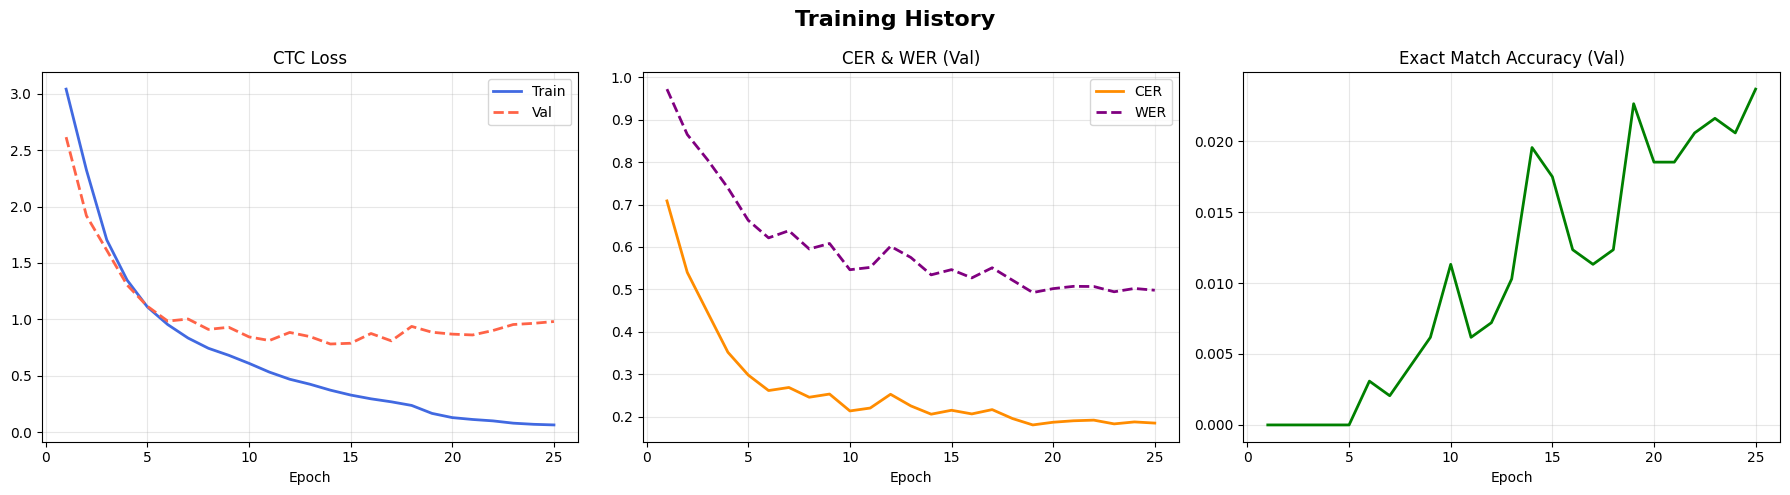

Plot saved: training_history.png


In [ ]:
import matplotlib.pyplot as plt

epochs_x = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

axes[0].plot(epochs_x, history['train_loss'], label='Train', color='royalblue', linewidth=2)
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   color='tomato',    linewidth=2, linestyle='--')
axes[0].set_title('CTC Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_x, history['val_cer'], label='CER', color='darkorange', linewidth=2)
axes[1].plot(epochs_x, history['val_wer'], label='WER', color='purple',     linewidth=2, linestyle='--')
axes[1].set_title('CER & WER (Val)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_x, history['val_acc'], color='green', linewidth=2)
axes[2].set_title('Exact Match Accuracy (Val)'); axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: training_history.png')


Final Test Evaluation


In [ ]:
checkpoint = torch.load('crnn_best.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model'])
c2i = checkpoint['c2i']
i2c = checkpoint['i2c']

test_metrics = compute_metrics(test_loader, model, criterion)

print('FINAL TEST RESULTS')
print(f"Test Loss       : {test_metrics['loss']:.4f}")
print(f"CER             : {test_metrics['CER']:.4f} ({test_metrics['CER']*100:.2f}%)")
print(f"WER             : {test_metrics['WER']:.4f} ({test_metrics['WER']*100:.2f}%)")
print(f"Exact Match Acc : {test_metrics['ExactMatch']:.4f} ({test_metrics['ExactMatch']*100:.2f}%)")

FINAL TEST RESULTS
Test Loss       : 0.8953
CER             : 0.1788 (17.88%)
WER             : 0.4767 (47.67%)
Exact Match Acc : 0.0236 (2.36%)


Inference  Predict

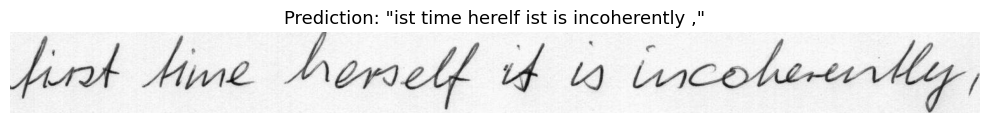

Ground Truth : "first time herself it is incoherently ,"
Predicted    : "ist time herelf ist is incoherently ,"


In [ ]:
def predict(img_input, show=True):

    if isinstance(img_input, str):
        img_input = Image.open(img_input)

    tensor = full_preprocessor(img_input).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        out = model(tensor).cpu()

    text = ctc_greedy_decode(out)[0]

    if show:
        plt.figure(figsize=(10, 2))
        plt.imshow(img_input.convert('L'), cmap='gray')
        plt.title(f'Prediction: "{text}"', fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return text


sample_idx = test_ds.indices[min(65, len(test_ds.indices)-1)]
sample     = raw[sample_idx]
predicted  = predict(sample['image'])
print(f'Ground Truth : "{sample["text"]}"')
print(f'Predicted    : "{predicted}"')

 Save Final Model

In [ ]:
torch.save({
    'model':       model.state_dict(),
    'c2i':         c2i,
    'i2c':         i2c,
    'test_metrics': test_metrics,
    'history':     history,
}, 'crnn_final.pth')
print('Model saved: crnn_final.pth')

Model saved: crnn_final.pth


English – Closest Character Suggestion Top-K

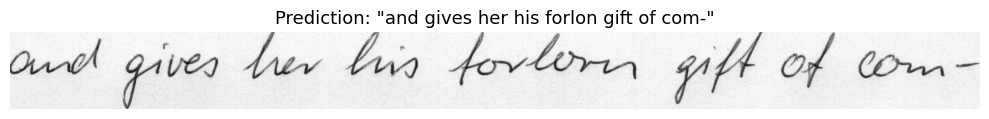

Ground Truth : 'and gives her his forlorn gift of com-'
Predicted    : 'and gives her his forlon gift of com-'

Step-by-step top-3 character alternatives:
  Position 01 → chosen: 'a'  | alternatives: [('a', 0.9998), ('A', 0.0001), ('o', 0.0)]
  Position 02 → chosen: 'n'  | alternatives: [('n', 0.9999), ('u', 0.0), ('<b>', 0.0)]
  Position 03 → chosen: 'd'  | alternatives: [('d', 0.9878), ('<b>', 0.0114), ('n', 0.0002)]
  Position 04 → chosen: ' '  | alternatives: [(' ', 1.0), ('<b>', 0.0), (',', 0.0)]
  Position 05 → chosen: 'g'  | alternatives: [('g', 0.9958), ('q', 0.002), ('y', 0.0006)]
  Position 06 → chosen: 'i'  | alternatives: [('i', 0.9999), ('r', 0.0), ('<b>', 0.0)]
  Position 07 → chosen: 'v'  | alternatives: [('v', 0.9994), ('r', 0.0006), ('s', 0.0)]
  Position 08 → chosen: 'e'  | alternatives: [('e', 0.9999), ('<b>', 0.0001), ('a', 0.0)]
  Position 09 → chosen: 's'  | alternatives: [('s', 0.9712), ('<b>', 0.0205), ('e', 0.007)]
  Position 10 → chosen: ' '  | alternatives: [

In [ ]:
import torch.nn.functional as F

def predict_english_topk(img_input, top_k=3, show=True):

    if isinstance(img_input, str):
        img_input = Image.open(img_input)

    tensor = full_preprocessor(img_input).unsqueeze(0).to(device)
    model.eval()

    with torch.no_grad():
        out = model(tensor).cpu()   # (T, 1, C)

    probs_all = F.softmax(out[:, 0, :], dim=-1)

    # Greedy decode with top-k tracking
    prev   = None
    tokens = []
    steps  = []

    for t in range(probs_all.size(0)):
        topk_probs, topk_ids = probs_all[t].topk(top_k)

        top_chars = [i2c.get(i.item(), '') for i in topk_ids]
        top_probs = [round(p.item(), 4) for p in topk_probs]

        best_id = topk_ids[0].item()

        # Only record a step when we emit a real character (CTC collapse)
        if best_id != prev and best_id != 0:   # 0 = CTC blank
            tokens.append(i2c.get(best_id, ''))
            steps.append({'top_chars': top_chars, 'top_probs': top_probs})

        prev = best_id

    decoded = ''.join(tokens)

    if show:
        plt.figure(figsize=(10, 2))
        plt.imshow(img_input.convert('L'), cmap='gray')
        plt.title(f'Prediction: "{decoded}"', fontsize=13)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    return decoded, steps

    #  Demo
sample_idx = test_ds.indices[min(10, len(test_ds.indices)-1)]
sample = raw[sample_idx]

pred, steps = predict_english_topk(sample['image'], top_k=3)

print(f"Ground Truth : '{sample['text']}'")
print(f"Predicted    : '{pred}'")
print()
print("Step-by-step top-3 character alternatives:")
for i, step in enumerate(steps[:len(pred)]):
    chosen = step["top_chars"][0]
    alts   = list(zip(step["top_chars"], step["top_probs"]))
    print(f"  Position {i+1:02d} → chosen: '{chosen}'  | alternatives: {alts}")

## Top-K Heatmap - Eng

Ground Truth: 'and gives her his forlorn gift of com-'


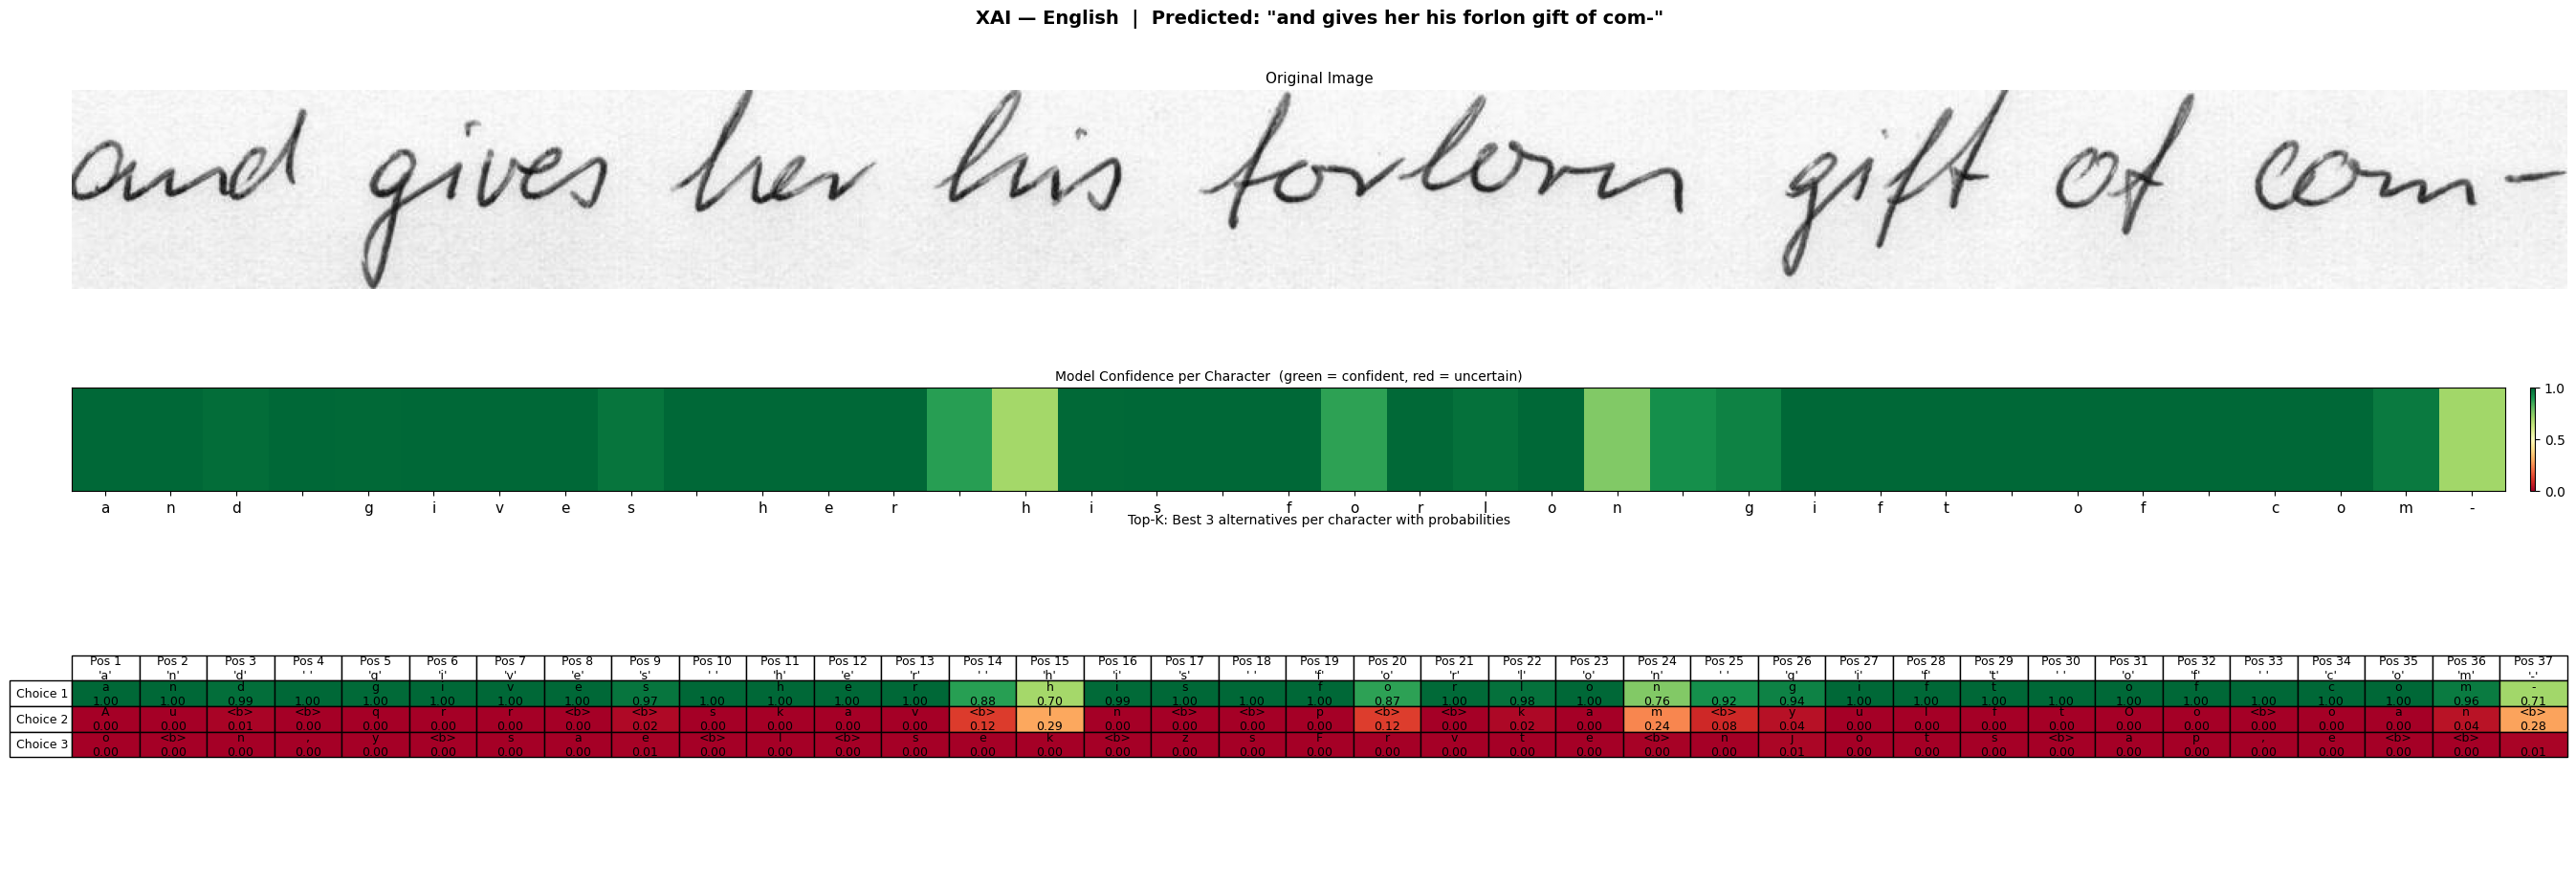

Predicted: and gives her his forlon gift of com-
Saved: xai_english.png


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

def xai_english_topk(img_input, top_k=3):


    if isinstance(img_input, str):
        img_input = Image.open(img_input)

    # Get predictions and steps
    pred_text, steps = predict_english_topk(img_input, top_k=top_k, show=False)

    if not steps:
        print("The model couldn't read the image.")
        return

    n_chars = len(steps)

    # Confidence of the top pick at each character position
    confidences = [step["top_probs"][0] for step in steps]

    # Drawing
    fig = plt.figure(figsize=(max(14, n_chars * 0.75), 9))
    fig.suptitle(
        f'XAI — English  |  Predicted: "{pred_text}"',
        fontsize=14, fontweight="bold", y=1.01
    )

    #  Section 1: Original Image
    ax_img = fig.add_axes([0.03, 0.65, 0.94, 0.30])
    ax_img.imshow(img_input.convert("L"), cmap="gray")
    ax_img.set_title("Original Image", fontsize=11)
    ax_img.axis("off")

    # Section 2: Confidence Heatmap
    ax_heat = fig.add_axes([0.03, 0.45, 0.94, 0.12])
    conf_array = np.array(confidences).reshape(1, -1)
    im = ax_heat.imshow(conf_array, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    ax_heat.set_xticks(range(n_chars))
    ax_heat.set_xticklabels(
        [step["top_chars"][0] for step in steps],
        fontsize=11
    )
    ax_heat.set_yticks([])
    ax_heat.set_title("Model Confidence per Character  (green = confident, red = uncertain)", fontsize=10)
    plt.colorbar(im, ax=ax_heat, orientation="vertical", fraction=0.015, pad=0.01)

    # Section 3: Top-K Table
    ax_table = fig.add_axes([0.03, 0.0, 0.94, 0.40])
    ax_table.axis("off")

    col_labels = [f"Pos {i+1}\n'{steps[i]['top_chars'][0]}'" for i in range(n_chars)]
    row_labels = [f"Choice {k+1}" for k in range(top_k)]

    table_data = []
    for k in range(top_k):
        row = []
        for i in range(n_chars):
            char = steps[i]["top_chars"][k] if k < len(steps[i]["top_chars"]) else "-"
            prob = steps[i]["top_probs"][k] if k < len(steps[i]["top_probs"]) else 0.0
            row.append(f"{char}\n{prob:.2f}")
        table_data.append(row)

    # Color each cell by its probability
    cell_colors = []
    cmap = plt.cm.RdYlGn
    for k in range(top_k):
        row_colors = []
        for i in range(n_chars):
            prob = steps[i]["top_probs"][k] if k < len(steps[i]["top_probs"]) else 0.0
            row_colors.append(cmap(prob))
        cell_colors.append(row_colors)

    tbl = ax_table.table(
        cellText=table_data,
        rowLabels=row_labels,
        colLabels=col_labels,
        cellColours=cell_colors,
        loc="center",
        cellLoc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)
    ax_table.set_title("Top-K: Best 3 alternatives per character with probabilities", fontsize=10, pad=8)

    plt.savefig("xai_english.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Predicted: {pred_text}")
    print("Saved: xai_english.png")


#  Run on a sample from the test set
sample_idx = test_ds.indices[min(10, len(test_ds.indices) - 1)]
sample = raw[sample_idx]

print(f"Ground Truth: '{sample['text']}'")
xai_english_topk(sample["image"], top_k=3)


Auto Language Detection + Upload - Arabic, English

Upload an image (Arabic or English handwriting):


Saving WhatsApp Image 2026-05-14 at 8.22.54 AM.jpeg to WhatsApp Image 2026-05-14 at 8.22.54 AM (5).jpeg


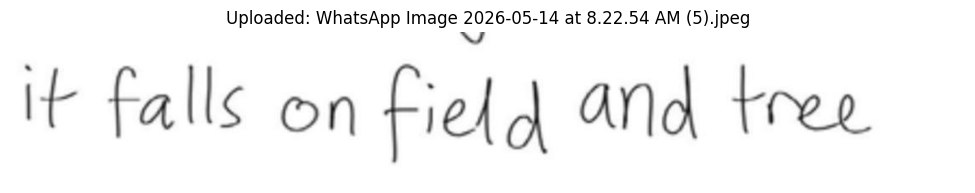


Detected Language: English
English Prediction: it fall an field and tree


In [ ]:
import unicodedata
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files


def detect_language_from_image(image: Image.Image) -> str:
    """
    Detect whether handwriting is Arabic or English.
    """

    # Arabic prediction
    try:
        arabic_pred, _ = predict_arabic_topk(
            arabic_model,
            image,
            max_len=20,
            top_k=1
        )

        if isinstance(arabic_pred, list):
            arabic_pred = arabic_pred[0]

        ar_count = sum(
            1 for ch in arabic_pred
            if '\u0600' <= ch <= '\u06FF'
        )

    except Exception:
        ar_count = 0

    # English prediction
    try:
        en_pred = predict_english_topk(
            image,
            top_k=1,
            show=False
        )

        # Remove extra outputs
        if isinstance(en_pred, tuple):
            en_pred = en_pred[0]

        if isinstance(en_pred, list):
            en_pred = en_pred[0]

        en_count = sum(
            1 for ch in en_pred
            if ch.isalpha() and ord(ch) < 128
        )

    except Exception:
        en_count = 0

    # Final decision
    return "english" if en_count >= ar_count else "arabic"


# Upload + Predict
print("Upload an image (Arabic or English handwriting):")

uploaded_files = files.upload()

for filename, file_bytes in uploaded_files.items():

    img = Image.open(BytesIO(file_bytes)).convert("RGB")

    # Show uploaded image
    plt.figure(figsize=(12, 2))
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"Uploaded: {filename}")
    plt.tight_layout()
    plt.show()

    # Detect language
    lang = detect_language_from_image(img)

    print(f"\nDetected Language: {'Arabic' if lang == 'arabic' else 'English'}")

    # Arabic OCR
    if lang == "arabic":

        pred_text, _ = predict_arabic_topk(
            arabic_model,
            img,
            top_k=2
        )

        if isinstance(pred_text, list):
            pred_text = pred_text[0]

        print(f"Arabic Prediction: {pred_text}")

    # English OCR
    else:

        pred_result = predict_english_topk(
            img,
            top_k=2,
            show=False
        )

        # Remove probabilities/details
        if isinstance(pred_result, tuple):
            pred_text = pred_result[0]
        else:
            pred_text = pred_result

        if isinstance(pred_text, list):
            pred_text = pred_text[0]

        print(f"English Prediction: {pred_text}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 15.1 MB/s eta 0:00:00
────────────────────────────────────────────────────────────
  ARABIC — Pre & Post Processing (3 Random Samples)
────────────────────────────────────────────────────────────


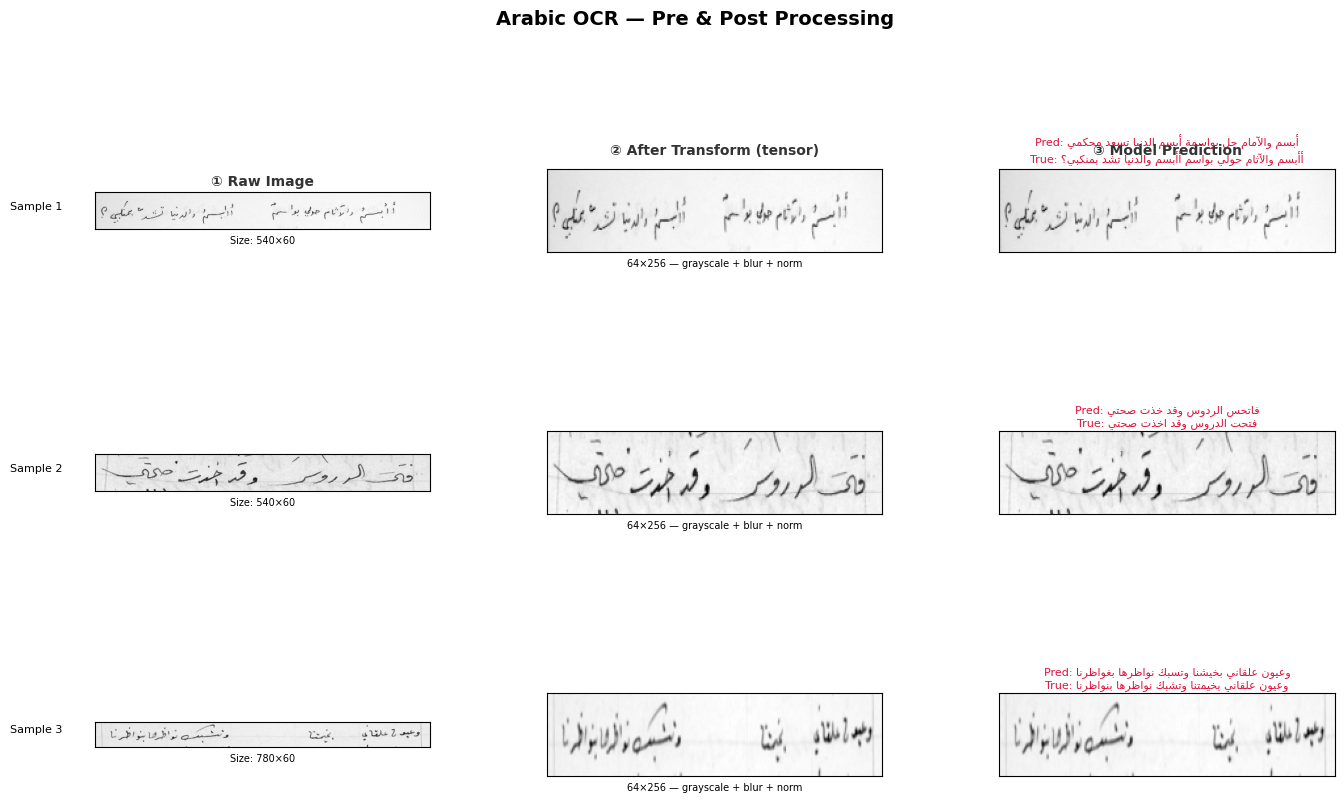


────────────────────────────────────────────────────────────
  ENGLISH — Pre & Post Processing (3 Random Samples)
────────────────────────────────────────────────────────────


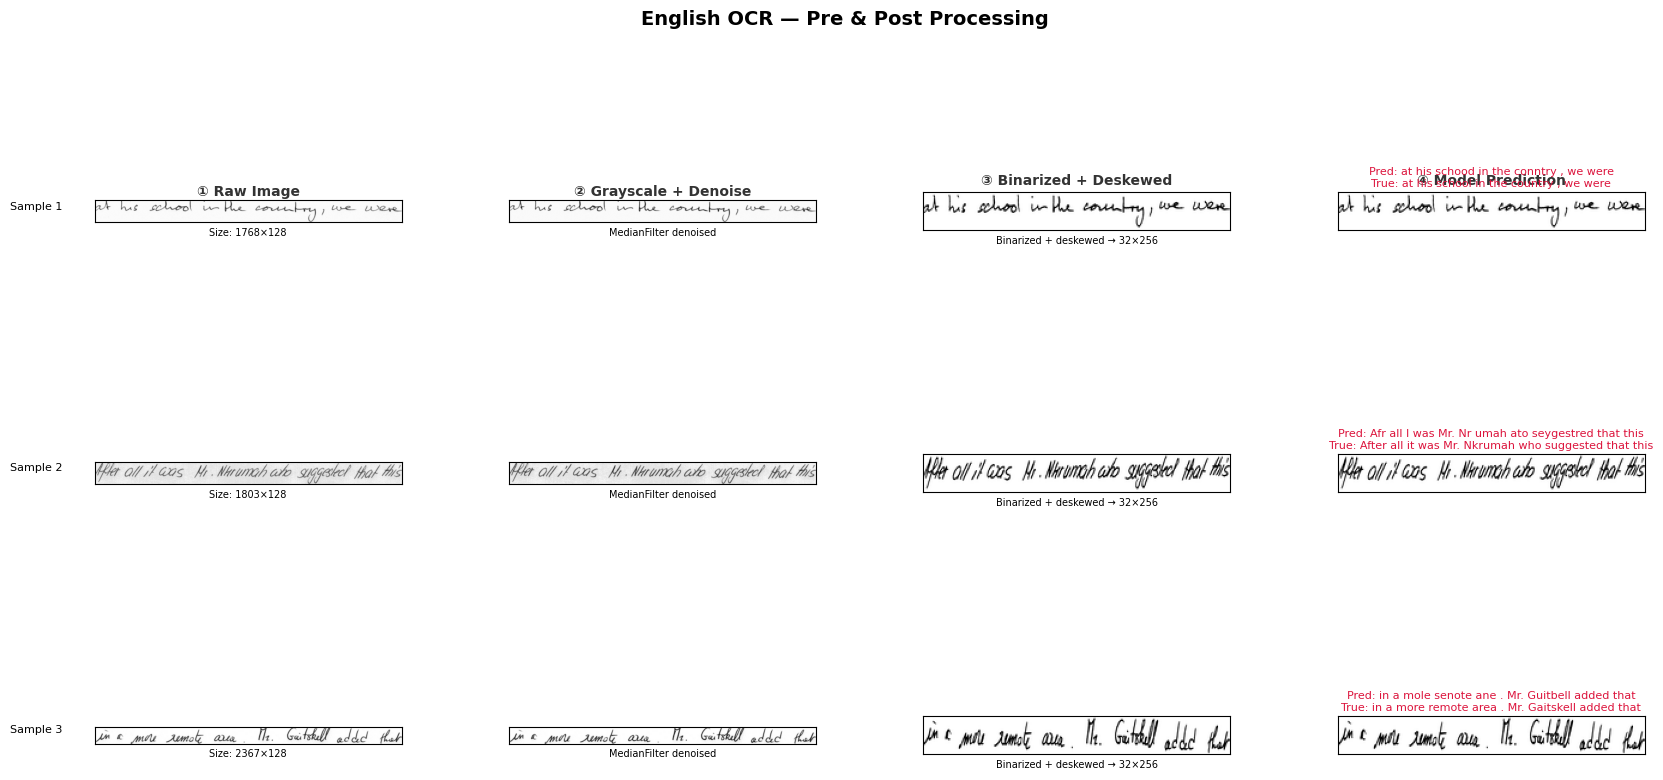

In [ ]:
!pip install arabic-reshaper python-bidi

import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from PIL import Image
from arabic_reshaper import reshape
from bidi.algorithm import get_display

def tensor_to_display(t):
    arr = t.squeeze().cpu().numpy()
    arr = arr * 0.5 + 0.5
    arr = np.clip(arr * 255, 0, 255).astype(np.uint8)
    return arr

def add_pred_title(ax, pred_text, true_text, lang):
    color = 'green' if pred_text.strip() == true_text.strip() else 'crimson'
    if lang == 'ar':
        pred_text = get_display(reshape(pred_text))
        true_text = get_display(reshape(true_text))
    ax.set_title(f'Pred: {pred_text}\nTrue: {true_text}',
                 fontsize=8, color=color, pad=4)

print('─' * 60)
print('  ARABIC — Pre & Post Processing (3 Random Samples)')
print('─' * 60)

ar_indices = random.sample(range(len(arabic_val_data)), 3)

fig_ar, axes_ar = plt.subplots(
    3, 3, figsize=(16, 9),
    gridspec_kw={'wspace': 0.35, 'hspace': 0.55}
)
fig_ar.suptitle('Arabic OCR — Pre & Post Processing', fontsize=14, fontweight='bold', y=1.01)

col_titles = ['① Raw Image', '② After Transform (tensor)', '③ Model Prediction']
for j, ct in enumerate(col_titles):
    axes_ar[0, j].text(0.5, 1.18, ct, transform=axes_ar[0, j].transAxes,
                        ha='center', fontsize=10, fontweight='bold', color='#333')

arabic_model.eval()

for row, idx in enumerate(ar_indices):
    item      = arabic_val_data[idx]
    raw_img   = item['image']
    true_text = clean_arabic_text(get_arabic_text(item))

    ax = axes_ar[row, 0]
    ax.imshow(raw_img.convert('L'), cmap='gray')
    ax.set_xlabel(f'Size: {raw_img.size[0]}×{raw_img.size[1]}', fontsize=7)
    ax.set_ylabel(f'Sample {row+1}', fontsize=8, rotation=0, labelpad=42)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    processed_t = arabic_test_transform(raw_img.convert('RGB'))
    proc_arr    = tensor_to_display(processed_t)
    ax2 = axes_ar[row, 1]
    ax2.imshow(proc_arr, cmap='gray')
    ax2.set_xlabel('64×256 — grayscale + blur + norm', fontsize=7)
    ax2.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    pred_text = predict_arabic(arabic_model, raw_img)
    ax3 = axes_ar[row, 2]
    ax3.imshow(proc_arr, cmap='gray')
    add_pred_title(ax3, pred_text, true_text, 'ar')
    ax3.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig('arabic_pre_post_processing.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('─' * 60)
print('  ENGLISH — Pre & Post Processing (3 Random Samples)')
print('─' * 60)

en_indices = random.sample(test_ds.indices, 3)

fig_en, axes_en = plt.subplots(
    3, 4, figsize=(20, 9),
    gridspec_kw={'wspace': 0.35, 'hspace': 0.55}
)
fig_en.suptitle('English OCR — Pre & Post Processing', fontsize=14, fontweight='bold', y=1.01)

en_col_titles = ['① Raw Image', '② Grayscale + Denoise', '③ Binarized + Deskewed', '④ Model Prediction']
for j, ct in enumerate(en_col_titles):
    axes_en[0, j].text(0.5, 1.18, ct, transform=axes_en[0, j].transAxes,
                        ha='center', fontsize=10, fontweight='bold', color='#333')

model.eval()
preprocessor = full_preprocessor

for row, idx in enumerate(en_indices):
    sample    = raw[idx]
    raw_img   = sample['image']
    true_text = sample['text'] or ''

    ax = axes_en[row, 0]
    ax.imshow(raw_img.convert('L'), cmap='gray')
    ax.set_xlabel(f'Size: {raw_img.size[0]}×{raw_img.size[1]}', fontsize=7)
    ax.set_ylabel(f'Sample {row+1}', fontsize=8, rotation=0, labelpad=42)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    step1 = preprocessor.to_grayscale(raw_img)
    step1 = preprocessor.denoise(step1)
    ax2 = axes_en[row, 1]
    ax2.imshow(np.array(step1), cmap='gray')
    ax2.set_xlabel('MedianFilter denoised', fontsize=7)
    ax2.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    step2 = preprocessor.binarize(step1)
    step2 = preprocessor.deskew(step2)
    step2 = preprocessor.aspect_resize(step2)
    ax3 = axes_en[row, 2]
    ax3.imshow(np.array(step2), cmap='gray')
    ax3.set_xlabel('Binarized + deskewed → 32×256', fontsize=7)
    ax3.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    pred_text = predict(raw_img, show=False)
    ax4 = axes_en[row, 3]
    ax4.imshow(np.array(step2), cmap='gray')
    add_pred_title(ax4, pred_text, true_text, 'en')
    ax4.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.tight_layout()
plt.savefig('english_pre_post_processing.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import os
import json
import csv
import io
from datetime import datetime
from PIL import Image
from google.colab import files


JSON_PATH = "ocr_results.json"
CSV_PATH  = "ocr_results.csv"

uploaded = files.upload()

if os.path.exists(JSON_PATH):
    with open(JSON_PATH, "r", encoding="utf-8") as f:
        try:
            all_results = json.load(f)
        except Exception:
            all_results = []
else:
    all_results = []

new_rows = []

for fname, fbytes in uploaded.items():

    image = Image.open(io.BytesIO(fbytes)).convert("RGB")

    try:
        lang = detect_language_from_image(image)

        # Force Arabic if prediction contains Arabic letters
        arabic_test, _ = predict_arabic_topk(
            arabic_model,
            image,
            top_k=1
        )

        if isinstance(arabic_test, list):
            arabic_test = arabic_test[0]

        if any('\u0600' <= ch <= '\u06FF' for ch in arabic_test):
            lang = "arabic"

    except Exception:
        lang = "english"

    if lang == "arabic":

        predicted_text, _ = predict_arabic_topk(
            arabic_model,
            image,
            top_k=2
        )

        if isinstance(predicted_text, list):
            predicted_text = predicted_text[0]

    else:

        predicted_text = predict_english_topk(
            image,
            top_k=2,
            show=False
        )

        if isinstance(predicted_text, tuple):
            predicted_text = predicted_text[0]

        if isinstance(predicted_text, list):
            predicted_text = predicted_text[0]

    record = {
        "filename": fname,
        "language": lang,
        "text": predicted_text,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
    }

    all_results.append(record)
    new_rows.append(record)

    print(f"File: {fname} | Detected Language: {lang}")
    print(f"Result: {predicted_text}")
    print("-" * 30)

with open(JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

write_header = not os.path.exists(CSV_PATH) or os.path.getsize(CSV_PATH) == 0

with open(CSV_PATH, "a", encoding="utf-8-sig", newline="") as f:

    writer = csv.DictWriter(
        f,
        fieldnames=["filename", "language", "text", "timestamp"]
    )

    if write_header:
        writer.writeheader()

    for row in new_rows:
        writer.writerow(row)

print(f"Saved: {JSON_PATH}, {CSV_PATH}")

files.download(JSON_PATH)
files.download(CSV_PATH)

Saving Screenshot 2026-05-30 020336.png to Screenshot 2026-05-30 020336.png
File: Screenshot 2026-05-30 020336.png | Detected Language: arabic
Result: الى عني النايه وادعو لنا بالنجاح واخبرني عن اخوالل لأن
------------------------------
Saved: ocr_results.json, ocr_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# DocOCR Vision
# AI-Powered Arabic & English Handwriting Recognition

!pip install gradio pandas -q

# Imports
import gradio as gr
import pandas as pd
import json
import os
from datetime import datetime
from PIL import Image
import matplotlib.pyplot as plt

# Create Save Folders
os.makedirs("saved_results/json", exist_ok=True)
os.makedirs("saved_results/csv", exist_ok=True)


# Main OCR Function
def run_complete_ocr(image):

    if image is None:
        return (
            "Please upload image",
            "",
            None,
            None
        )

    # Auto Language Detection
    detected_lang = detect_language_from_image(image)

    # Arabic Model
    if detected_lang == "arabic":

        predicted_text, steps = predict_arabic_topk(
            arabic_model,
            image,
            top_k=3
        )

        language_name = "Arabic"

    # English Model
    else:

        predicted_text, steps = predict_english_topk(
            image,
            top_k=3,
            show=False
        )

        language_name = "English"

    # Format Top-K Results
    topk_output = ""

    for i, step in enumerate(steps[:len(predicted_text)]):

        alternatives = list(
            zip(
                step["top_chars"],
                step["top_probs"]
            )
        )

        topk_output += (
            f"Position {i+1:02d}\n"
            f"{alternatives}\n\n"
        )

    # Save Results
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    result_data = {
        "timestamp": timestamp,
        "system_name": "DocOCR Vision",
        "language": language_name,
        "predicted_text": predicted_text,
        "topk_predictions": steps
    }

    # Save JSON
    json_path = (
        f"saved_results/json/"
        f"ocr_result_{timestamp}.json"
    )

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(
            result_data,
            f,
            ensure_ascii=False,
            indent=4
        )

    # Save CSV
    csv_data = []

    for i, step in enumerate(steps):

        csv_data.append({
            "position": i + 1,
            "top_chars": str(step["top_chars"]),
            "top_probs": str(step["top_probs"])
        })

    csv_df = pd.DataFrame(csv_data)

    csv_path = (
        f"saved_results/csv/"
        f"ocr_result_{timestamp}.csv"
    )

    csv_df.to_csv(
        csv_path,
        index=False,
        encoding="utf-8-sig"
    )

    # Final Output
    final_output = f"""
DocOCR Vision

Detected Language:
{language_name}

Extracted Text:
{predicted_text}

Saved Files:
JSON → {json_path}

CSV → {csv_path}
"""

    return (
        final_output,
        topk_output,
        json_path,
        csv_path
    )


# Image Preview
def preview_image(image):

    if image is None:
        return None

    plt.figure(figsize=(12, 3))
    plt.imshow(image.convert("L"), cmap="gray")
    plt.axis("off")

    preview_path = "preview_image.png"

    plt.savefig(
        preview_path,
        bbox_inches="tight"
    )

    plt.close()

    return preview_path


# Gradio UI
with gr.Blocks(
    theme=gr.themes.Soft(),
    title="DocOCR Vision"
) as demo:

    gr.Markdown("""
    # DocOCR Vision

    ## AI-Powered Arabic & English Handwriting Recognition

    ### Automatic Language Detection & Smart OCR Extraction
    """)

    # Image Upload + Preview
    with gr.Row():

        image_input = gr.Image(
            type="pil",
            label="Upload Handwritten Image"
        )

        preview_output = gr.Image(
            label="Image Preview"
        )

    # Buttons
    with gr.Row():

        preview_btn = gr.Button(
            "Preview Image"
        )

        extract_btn = gr.Button(
            "Extract Text",
            variant="primary"
        )

    preview_btn.click(
        fn=preview_image,
        inputs=image_input,
        outputs=preview_output
    )

    # Output Section
    with gr.Row():

        result_output = gr.Textbox(
            label="OCR Result",
            lines=12,
            max_lines=20,
            scale=1
        )

        topk_output = gr.Textbox(
            label="Top-K Character Alternatives",
            lines=12,
            max_lines=20,
            scale=1
        )

    # Download Files
    with gr.Row():

        json_file = gr.File(
            label="Download JSON Result"
        )

        csv_file = gr.File(
            label="Download CSV Result"
        )

    extract_btn.click(
        fn=run_complete_ocr,
        inputs=image_input,
        outputs=[
            result_output,
            topk_output,
            json_file,
            csv_file
        ]
    )

# Launch App
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1556929d49c63426a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import json, csv
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Arabic metrics from training history
arabic_cer = arabic_cer_scores[-1]
arabic_wer = arabic_wer_scores[-1]

# Arabic
torch.save({
    "model_state_dict": arabic_model.state_dict(),
    "ar_itos":          ar_itos,
    "ar_stoi":          ar_stoi,
    "ar_pad_id":        ar_pad_id,
    "ar_sos_id":        ar_sos_id,
    "ar_eos_id":        ar_eos_id,
    "ar_vocab_size":    ar_vocab_size,
    "train_losses":     arabic_train_losses,
    "val_losses":       arabic_val_losses,
    "CER":              arabic_cer,
    "WER":              arabic_wer,
}, f"arabic_model_{timestamp}.pth")

# English
torch.save({
    "model_state_dict": model.state_dict(),
    "c2i":              c2i,
    "i2c":              i2c,
    "test_metrics":     test_metrics,
    "history":          history,
}, f"english_model_{timestamp}.pth")

# JSON
metadata = {
    "timestamp": timestamp,
    "arabic": {
        "vocab_size":    ar_vocab_size,
        "CER":           round(arabic_cer, 4),
        "WER":           round(arabic_wer, 4),
        "epochs":        len(arabic_train_losses),
        "best_val_loss": round(min(arabic_val_losses), 4),
        "train_losses":  [round(l, 4) for l in arabic_train_losses],
        "val_losses":    [round(l, 4) for l in arabic_val_losses],
    },
    "english": {
        "vocab_size":   len(chars),
        "CER":          round(test_metrics["CER"], 4),
        "WER":          round(test_metrics["WER"], 4),
        "ExactMatch":   round(test_metrics["ExactMatch"], 4),
        "epochs":       len(history["train_loss"]),
        "best_val_cer": round(min(history["val_cer"]), 4),
        "train_losses": [round(l, 4) for l in history["train_loss"]],
        "val_losses":   [round(l, 4) for l in history["val_loss"]],
        "val_cer":      [round(v, 4) for v in history["val_cer"]],
        "val_wer":      [round(v, 4) for v in history["val_wer"]],
        "val_acc":      [round(v, 4) for v in history["val_acc"]],
    }
}

with open(f"ocr_metadata_{timestamp}.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

#  CSV
with open(f"ocr_summary_{timestamp}.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)

    writer.writerow(["Model", "Metric", "Value"])

    writer.writerow(["Arabic", "CER", round(arabic_cer, 4)])
    writer.writerow(["Arabic", "WER", round(arabic_wer, 4)])
    writer.writerow(["Arabic", "Epochs", len(arabic_train_losses)])
    writer.writerow(["Arabic", "Best Val Loss", round(min(arabic_val_losses), 4)])

    writer.writerow(["English", "CER", round(test_metrics["CER"], 4)])
    writer.writerow(["English", "WER", round(test_metrics["WER"], 4)])
    writer.writerow(["English", "Exact Match", round(test_metrics["ExactMatch"], 4)])
    writer.writerow(["English", "Epochs", len(history["train_loss"])])
    writer.writerow(["English", "Best Val CER", round(min(history["val_cer"]), 4)])

    for i, (tl, vl) in enumerate(zip(arabic_train_losses, arabic_val_losses)):
        writer.writerow([f"Arabic Epoch {i+1}", "Train Loss", round(tl, 4)])
        writer.writerow([f"Arabic Epoch {i+1}", "Val Loss", round(vl, 4)])

    for i, (tl, vl, vc, vw, va) in enumerate(zip(
        history["train_loss"],
        history["val_loss"],
        history["val_cer"],
        history["val_wer"],
        history["val_acc"]
    )):
        writer.writerow([f"English Epoch {i+1}", "Train Loss", round(tl, 4)])
        writer.writerow([f"English Epoch {i+1}", "Val Loss", round(vl, 4)])
        writer.writerow([f"English Epoch {i+1}", "Val CER", round(vc, 4)])
        writer.writerow([f"English Epoch {i+1}", "Val WER", round(vw, 4)])
        writer.writerow([f"English Epoch {i+1}", "Val Acc", round(va, 4)])

print(f"arabic_model_{timestamp}.pth")
print(f"english_model_{timestamp}.pth")
print(f"ocr_metadata_{timestamp}.json")
print(f"ocr_summary_{timestamp}.csv")

arabic_model_20260529_230803.pth
english_model_20260529_230803.pth
ocr_metadata_20260529_230803.json
ocr_summary_20260529_230803.csv
